# PEFT LoRA 튜토리얼: 한국어 QA Fine-tuning 실습

**데이터**: KorQuAD 1.0 (한국어 SQuAD)  
**모델**: Qwen/Qwen2.5-0.5B (Alibaba Qwen 시리즈, 5억 파라미터)

이 노트북에서는 다음을 실습합니다:
1. 다국어 GPT 모델에 LoRA adapter 주입
2. KorQuAD 데이터로 QA fine-tuning 수행
3. 학습 전/후 한국어 QA 성능 비교 (정성 + 정량 평가)
4. 모델 저장 및 로드

> ⚙️ Colab에서 **GPU 런타임**을 선택하세요: 런타임 → 런타임 유형 변경 → T4 GPU

## 0. 환경 설정

In [1]:
# 필요한 라이브러리 설치
!pip install -q peft accelerate datasets

In [2]:
import torch

# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

사용 디바이스: cuda
GPU: Tesla T4
VRAM: 14.6 GB


## 1. LoRA Configuration 설정

| 파라미터 | 값 | 설명 |
|---------|---|------|
| `r` | 32 | Low-rank 행렬의 rank |
| `lora_alpha` | 32 | Scaling factor |
| `target_modules` | all-linear | 모든 linear layer에 LoRA 적용 |
| `lora_dropout` | 0.05 | 과적합 방지 |
| `task_type` | CAUSAL_LM | 다음 토큰 예측 (생성 태스크) |

In [3]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    r=32,                                # rank: low-rank 행렬의 차원
    target_modules="all-linear",          # 모든 linear layer에 LoRA 적용
    task_type=TaskType.CAUSAL_LM,        # Causal Language Modeling
    lora_alpha=32,                       # scaling factor
    lora_dropout=0.05                    # dropout
)

print(lora_config)

LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.18.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=32, target_modules='all-linear', exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, arrow_config=None, ensure_weight_tying=False)


## 2. Base Model 로드

**Qwen/Qwen2.5-0.5B**  
- Alibaba Qwen 시리즈의 경량 모델 (5억 파라미터)  
- 다국어 대규모 코퍼스로 사전학습 (한국어 포함)  
- 0.5B라 Colab T4에서 빠르게 학습 가능 → LoRA 효과를 체감하기 좋음  
- HuggingFace: https://huggingface.co/Qwen/Qwen2.5-0.5B

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B"

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Base 모델 로드 (fp16으로 메모리 절약)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 패딩 토큰 설정
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

print(f"모델: {model_name}")
print(f"파라미터 수: {model.num_parameters():,}")
print(f"토크나이저 vocab 크기: {len(tokenizer):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

모델: Qwen/Qwen2.5-0.5B
파라미터 수: 494,032,768
토크나이저 vocab 크기: 151,665


## 3. PeftModel 생성

`get_peft_model()`로 base model에 LoRA adapter를 주입합니다.  
원래 weights는 freeze, LoRA A/B 행렬만 학습됩니다.

In [5]:
from peft import get_peft_model

lora_model = get_peft_model(model, lora_config)
lora_model.print_trainable_parameters()

trainable params: 17,596,416 || all params: 511,629,184 || trainable%: 3.4393


In [6]:
# LoRA가 적용된 레이어 확인
trainable_params = [(name, param.shape) for name, param in lora_model.named_parameters() if param.requires_grad]
print(f"학습 가능한 파라미터 그룹 수: {len(trainable_params)}\n")
for name, shape in trainable_params[:10]:  # 처음 10개만
    print(f"  ✅ {name} | {shape}")
if len(trainable_params) > 10:
    print(f"  ... 외 {len(trainable_params) - 10}개")

학습 가능한 파라미터 그룹 수: 336

  ✅ base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight | torch.Size([32, 896])
  ✅ base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight | torch.Size([896, 32])
  ✅ base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight | torch.Size([32, 896])
  ✅ base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight | torch.Size([128, 32])
  ✅ base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight | torch.Size([32, 896])
  ✅ base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight | torch.Size([128, 32])
  ✅ base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight | torch.Size([32, 896])
  ✅ base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight | torch.Size([896, 32])
  ✅ base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight | torch.Size([32, 896])
  ✅ base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight | torch.Size([486

## 4. 한국어 QA 학습 데이터 준비

### 데이터셋: KorQuAD 1.0 (Korean Question Answering Dataset)

SQuAD v1.0의 한국어 버전으로, 한국어 Wikipedia 문단에서 질문에 대한 답을 찾는 QA 데이터셋입니다.  
학습 데이터 60,407개, 검증 데이터 5,774개로 구성되어 있습니다.

```
문맥: {한국어 Wikipedia 문단}
질문: {질문}
답변: {정답}
```

- 공식 사이트: https://korquad.github.io/
- HuggingFace: https://huggingface.co/datasets/KorQuAD/squad_kor_v1

In [10]:
from datasets import load_dataset

# KorQuAD 1.0 데이터 로드
dataset = load_dataset("KorQuAD/squad_kor_v1", split="train")
print(f"전체 학습 데이터 수: {len(dataset):,}")

# 예시 확인
for i in [0, 1000]:
    example = dataset[i]
    print(f"\n{'='*50}")
    print(f"제목: {example['title']}")
    print(f"문맥: {example['context'][:150]}...")
    print(f"질문: {example['question']}")
    print(f"답변: {example['answers']['text'][0]}")

전체 학습 데이터 수: 60,407

제목: 파우스트_서곡
문맥: 1839년 바그너는 괴테의 파우스트을 처음 읽고 그 내용에 마음이 끌려 이를 소재로 해서 하나의 교향곡을 쓰려는 뜻을 갖는다. 이 시기 바그너는 1838년에 빛 독촉으로 산전수전을 다 걲은 상황이라 좌절과 실망에 가득했으며 메피스토펠레스를 만나는 파우스트의 심경에 공감...
질문: 바그너는 괴테의 파우스트를 읽고 무엇을 쓰고자 했는가?
답변: 교향곡

제목: 맨체스터_시티_FC
문맥: 머서의 지휘 첫시즌인 1965 - 66시즌, 맨체스터 시티는 2부리그 우승을 차지하고 콜린 벨과 마이크 서머비 영입에 성공하게 된다. 다음시즌은 1부리그에서 15위를 기록하게 되는데 시즌 막판 17경기에서 단 4패에 그치는 놀라운 성적을 거두게 된다. 1967 - 68...
질문: 맨체스터 시티가 맨체스터 유나이티드를 3-1로 승리한 경기는 어디에서 이루어졌는가?
답변: 올드 트래퍼드


In [11]:
# Colab T4에서 실습 가능한 크기로 샘플링
TRAIN_SIZE = 5000
EVAL_SIZE = 200

small_dataset = dataset.shuffle(seed=42).select(range(TRAIN_SIZE + EVAL_SIZE))
train_dataset = small_dataset.select(range(TRAIN_SIZE))
eval_dataset = small_dataset.select(range(TRAIN_SIZE, TRAIN_SIZE + EVAL_SIZE))

print(f"학습 데이터: {len(train_dataset)}개")
print(f"평가 데이터: {len(eval_dataset)}개")

학습 데이터: 5000개
평가 데이터: 200개


### 데이터 전처리

QA를 Causal LM 포맷으로 변환합니다.  
모델이 `답변:` 이후 부분만 생성하도록 **labels masking**을 적용합니다.

In [12]:
MAX_LENGTH = 256

def format_qa(example):
    """KorQuAD 예제를 생성형 QA 텍스트로 변환"""
    context = example["context"][:300]  # context 길이 제한
    question = example["question"]
    answer = example["answers"]["text"][0]

    # 한국어 프롬프트 포맷
    prompt = f"문맥: {context}\n질문: {question}\n답변:"
    full_text = f"{prompt} {answer}{tokenizer.eos_token}"

    return {"prompt": prompt, "full_text": full_text}

# 포맷 적용
train_dataset = train_dataset.map(format_qa)
eval_dataset = eval_dataset.map(format_qa)

print("=== 변환된 예시 ===")
print(train_dataset[0]["full_text"][:400])

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

=== 변환된 예시 ===
문맥: 9월 26일 환경부를 비롯한 12개 관계부처가 합동으로 '미세먼지 관리 종합대책'을 확정하고 발전·산업·수송·생활 등 4개 부분에서 저감 대책을 실시하는 관련 로드맵을 발표했다. 7조 2000억 원의 예산을 투입해 미세먼지 국내 배출량을 30% 감축하고 미세먼지 '나쁨' 일수를 70%까지 줄이기로 한 것인데 이를 위해 공정률 10% 미만인 석탄발전소 9기 중 4기를 LNG 등 친환경 연료로 전환하고 남은 5기도 최고 수준의 배출 기준을 적용하며 30년이 넘은 노후 석탄발전소 7기는 임기 내 폐쇄하기로 했다. 또한 대기배출총량제를 전
질문: 미세먼지 해결을 위해 전국으로 확대 강화된 기존의 제도는?
답변: 대기배출총량제<|endoftext|>


PyTorch의 CrossEntropyLoss에서 ignore_index의 기본값이 -100입니다.
label이 -100인 위치는 loss 계산에서 완전히 제외됩니다. 즉, 그 토큰은 "맞추든 틀리든 상관없다"는 의미입니다.

In [13]:
def tokenize_fn(examples):
    """토크나이징 + labels masking (프롬프트 부분은 -100으로)"""
    model_inputs = tokenizer(
        examples["full_text"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length"
    )

    labels = []
    for i, prompt in enumerate(examples["prompt"]):
        prompt_len = len(tokenizer(prompt, truncation=True, max_length=MAX_LENGTH)["input_ids"])
        label = model_inputs["input_ids"][i].copy()
        # 프롬프트 부분은 loss 계산에서 제외 (-100)
        label[:prompt_len] = [-100] * prompt_len
        # 패딩 부분도 제외
        label = [-100 if token == tokenizer.pad_token_id else l
                 for token, l in zip(model_inputs["input_ids"][i], label)]
        labels.append(label)

    model_inputs["labels"] = labels
    return model_inputs

# 토크나이징 적용
tokenized_train = train_dataset.map(tokenize_fn, batched=True, remove_columns=train_dataset.column_names)
tokenized_eval = eval_dataset.map(tokenize_fn, batched=True, remove_columns=eval_dataset.column_names)

print(f"토크나이징 완료")
print(f"  학습 데이터 컬럼: {tokenized_train.column_names}")
print(f"  입력 시퀀스 길이: {len(tokenized_train[0]['input_ids'])}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

토크나이징 완료
  학습 데이터 컬럼: ['input_ids', 'attention_mask', 'labels']
  입력 시퀀스 길이: 256


## 5. 학습 전 성능 확인 (baseline)

학습 전에 모델이 한국어 QA를 어떻게 하는지 확인합니다.  
**정성 평가**(생성 텍스트 비교)와 **정량 평가**(Perplexity)를 모두 수행합니다.

In [15]:
def generate_answer(model, question, context, max_new_tokens=50):
    """주어진 문맥과 질문으로 답변 생성"""
    prompt = f"문맥: {context}\n질문: {question}\n답변:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id   # ← 이거 추가
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # "답변:" 이후 부분만 추출
    answer = full_output.split("답변:")[-1].strip()
    return answer

# 테스트 샘플 5개
test_samples = eval_dataset.select(range(5))

# ── 학습 전 생성 결과 저장 ──
baseline_preds = []

print("=" * 60)
print("📋 학습 전 (baseline) 생성 결과")
print("=" * 60)

for i, sample in enumerate(test_samples):
    pred = generate_answer(lora_model, sample["question"], sample["context"][:300])
    gold = sample["answers"]["text"][0]
    baseline_preds.append(pred)
    print(f"\n[{i+1}] 질문: {sample['question']}")
    print(f"    정답: {gold}")
    print(f"    예측: {pred[:100]}")

📋 학습 전 (baseline) 생성 결과

[1] 질문: 율곡이이 어머니의 이름은?
    정답: 신사임당
    예측: 율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어

[2] 질문: 태양이 우주를 움직이는 주요한 원천이라고 주장하는 학문은?
    정답: 지동설
    예측: 태양은 우주를 움직이는 주요한 원천이라고 주장하는 학문은 "우주는 태양을 움직이는 주요한 원천"이라고 주장하는 학문입니다. 이

[3] 질문: 영국의 지배에 봉기한 13개 식민지를 승계한 주는?
    정답: 최초의 13개 주
    예측: 영국의 지배에 봉기한 13개 식민지를 승계한 주는 버지니아, 켄터키, 테네시, 메인, 텍사스, 하

[4] 질문: 일본에 우편물을 보낼때 쓰는 국가기호는?
    정답: JP
    예측: 일본에 우편물을 보낼때 쓰는 국가기호는 일본이다.

[5] 질문: Finn Williams 는 시티즈 스카이라인에서 무엇을 실험하길 원했을까?
    정답: 대안 경제모델
    예측: 시티즈 스카이라인에서 대안 경제모델을 실험하길 원했다.


## 6. Trainer 준비 & 학습 전 Perplexity 측정

학습 전에 eval perplexity를 먼저 측정해 둡니다.  
학습 후와 비교하면 LoRA의 효과를 **수치로** 확인할 수 있습니다.

In [16]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

training_args = TrainingArguments(
    output_dir="./lora-korquad-checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,        # effective batch = 8 * 2 = 16
    learning_rate=3e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # Causal LM
)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    data_collator=data_collator,
)

print("✅ Trainer 준비 완료")
print(f"  모델: {model_name}")
print(f"  학습 데이터: {len(tokenized_train)}개")
print(f"  평가 데이터: {len(tokenized_eval)}개")
print(f"  에폭: {training_args.num_train_epochs}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Trainer 준비 완료
  모델: Qwen/Qwen2.5-0.5B
  학습 데이터: 5000개
  평가 데이터: 200개
  에폭: 3
  Effective batch size: 16


**Perplexity = 모델이 다음 토큰을 예측할 때 느끼는 "혼란도"**  

Perplexity가 100이면 → 모델이 매 토큰마다 "100개 후보 중 하나"를 찍는 수준의 불확실성을 느낀다는 뜻  
- 1 : 다음 토큰을 100% 확신, 10 : 꽤 잘 알고 있음, 100 : 많이 헷갈림

In [17]:
# ── 학습 전 Perplexity 측정 ──
baseline_eval = trainer.evaluate()
baseline_ppl = torch.exp(torch.tensor(baseline_eval['eval_loss'])).item()
print(f"📊 학습 전 Eval Loss: {baseline_eval['eval_loss']:.4f}")
print(f"📊 학습 전 Perplexity: {baseline_ppl:.2f}")

📊 학습 전 Eval Loss: 2.8060
📊 학습 전 Perplexity: 16.54


## 7. LoRA Fine-tuning 실행

In [18]:
# 🚀 학습 시작!
print("학습을 시작합니다...\n")
train_result = trainer.train()

print(f"\n{'=' * 40}")
print(f"✅ 학습 완료!")
print(f"  Total steps: {train_result.global_step}")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  학습 시간: {train_result.metrics['train_runtime']:.1f}초")

학습을 시작합니다...



Epoch,Training Loss,Validation Loss,Model Preparation Time
1,2.496847,2.480163,0.015300
2,2.242803,2.365524,0.015300
3,2.012705,2.343204,0.015300



✅ 학습 완료!
  Total steps: 939
  Training loss: 2.3015
  학습 시간: 1152.9초


## 8. 학습 전/후 정량 비교

### 8-1. Perplexity 비교

Perplexity가 낮을수록 모델이 정답 토큰을 잘 예측한다는 의미입니다.

In [19]:
# ── 학습 후 Perplexity 측정 ──
lora_model.eval()
after_eval = trainer.evaluate()
after_ppl = torch.exp(torch.tensor(after_eval['eval_loss'])).item()

print("=" * 50)
print("📊 Perplexity 비교")
print("=" * 50)
print(f"  학습 전: {baseline_ppl:.2f}")
print(f"  학습 후: {after_ppl:.2f}")
print(f"  개선율:  {(baseline_ppl - after_ppl) / baseline_ppl * 100:.1f}%")
print()
print(f"  학습 전 Eval Loss: {baseline_eval['eval_loss']:.4f}")
print(f"  학습 후 Eval Loss: {after_eval['eval_loss']:.4f}")

📊 Perplexity 비교
  학습 전: 16.54
  학습 후: 10.41
  개선율:  37.0%

  학습 전 Eval Loss: 2.8060
  학습 후 Eval Loss: 2.3432


### 8-2. Training Loss Curve

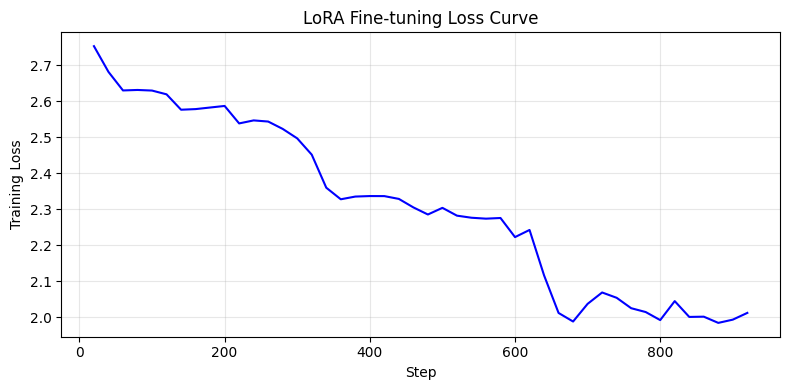

초기 loss: 2.7527 → 최종 loss: 2.0127


In [20]:
import matplotlib.pyplot as plt

logs = [l for l in trainer.state.log_history if 'loss' in l]
steps = [l['step'] for l in logs]
losses = [l['loss'] for l in logs]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, 'b-', linewidth=1.5)
plt.xlabel('Step')
plt.ylabel('Training Loss')
plt.title('LoRA Fine-tuning Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"초기 loss: {losses[0]:.4f} → 최종 loss: {losses[-1]:.4f}")

### 8-3. 학습 전/후 생성 결과 비교

동일한 테스트 샘플로 학습 전/후를 나란히 비교합니다.

In [21]:
print("=" * 70)
print("📋 학습 전/후 생성 결과 비교")
print("=" * 70)

for i, sample in enumerate(test_samples):
    pred_after = generate_answer(lora_model, sample["question"], sample["context"][:300])
    gold = sample["answers"]["text"][0]
    pred_before = baseline_preds[i]

    # 정답 포함 여부 체크
    before_ok = gold in pred_before
    after_ok = gold in pred_after

    print(f"\n[{i+1}] 질문: {sample['question']}")
    print(f"    정답:     {gold}")
    print(f"    학습 전:  {pred_before[:100]}  {'✅' if before_ok else '❌'}")
    print(f"    학습 후:  {pred_after[:100]}  {'✅' if after_ok else '❌'}")

📋 학습 전/후 생성 결과 비교

[1] 질문: 율곡이이 어머니의 이름은?
    정답:     신사임당
    학습 전:  율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어  ❌
    학습 후:  신사임당의 어머니는 율곡이 이이의 어  ✅

[2] 질문: 태양이 우주를 움직이는 주요한 원천이라고 주장하는 학문은?
    정답:     지동설
    학습 전:  태양은 우주를 움직이는 주요한 원천이라고 주장하는 학문은 "우주는 태양을 움직이는 주요한 원천"이라고 주장하는 학문입니다. 이  ❌
    학습 후:  우주론자학(宇宙論家學)이라고 하며, 이는 케플러가 1596년에 발표한 《우주론자학》(De Revolutionibus Orbium Coelstion  ❌

[3] 질문: 영국의 지배에 봉기한 13개 식민지를 승계한 주는?
    정답:     최초의 13개 주
    학습 전:  영국의 지배에 봉기한 13개 식민지를 승계한 주는 버지니아, 켄터키, 테네시, 메인, 텍사스, 하  ❌
    학습 후:  버지니아에서 켄터키가, 노스캐롤  ❌

[4] 질문: 일본에 우편물을 보낼때 쓰는 국가기호는?
    정답:     JP
    학습 전:  일본에 우편물을 보낼때 쓰는 국가기호는 일본이다.  ❌
    학습 후:  일본어: 일본인(영어: Japanese) 또는 일본인(영어: Japanese people)이라고 하며, 이는 일본인의 언어를 가진 사람을 의미하며, 이는 일본인들의 문화적 특  ❌

[5] 질문: Finn Williams 는 시티즈 스카이라인에서 무엇을 실험하길 원했을까?
    정답:     대안 경제모델
    학습 전:  시티즈 스카이라인에서 대안 경제모델을 실험하길 원했다.  ✅
    학습 후:  Finn  ❌


## 9. 모델 저장 & 로드

In [23]:
# adapter 저장
save_path = "./qwen2.5-lora-korquad"
lora_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# 저장된 파일 확인
import os
total_size = 0
print("저장된 파일:")
for f in sorted(os.listdir(save_path)):
    size = os.path.getsize(os.path.join(save_path, f))
    total_size += size
    print(f"  {f} ({size / 1024:.1f} KB)")
print(f"\n총 adapter 크기: {total_size / 1024 / 1024:.1f} MB")
print(f"(참고: base model 전체는 ~1 GB)")

저장된 파일:
  README.md (5.1 KB)
  adapter_config.json (1.0 KB)
  adapter_model.safetensors (68779.3 KB)
  chat_template.jinja (2.4 KB)
  tokenizer.json (11154.2 KB)
  tokenizer_config.json (0.7 KB)

총 adapter 크기: 78.1 MB
(참고: base model 전체는 ~1 GB)


In [24]:
from peft import PeftModel, PeftConfig

# 저장된 adapter 다시 로드
config = PeftConfig.from_pretrained(save_path)
print(f"Base model: {config.base_model_name_or_path}")

base_model = AutoModelForCausalLM.from_pretrained(
    config.base_model_name_or_path,
    torch_dtype=torch.float16,
    device_map="auto"
)
loaded_model = PeftModel.from_pretrained(base_model, save_path)
loaded_model.eval()

# 로드된 모델로 테스트
sample = eval_dataset[0]
pred = generate_answer(loaded_model, sample["question"], sample["context"][:300])
print(f"\n질문: {sample['question']}")
print(f"정답: {sample['answers']['text'][0]}")
print(f"예측: {pred}")
print(f"\n✅ 저장된 adapter 로드 & 추론 성공")

Base model: Qwen/Qwen2.5-0.5B


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


질문: 율곡이이 어머니의 이름은?
정답: 신사임당
예측: 신사임당의 어머니는 율곡이 이이의 어

✅ 저장된 adapter 로드 & 추론 성공


## 10. Merge & Unload (선택)

서빙 시 adapter를 base에 합쳐서 추론 속도를 개선할 수 있습니다.

> ⚠️ merge 후에는 adapter를 분리할 수 없습니다.

In [25]:
merged_model = loaded_model.merge_and_unload()
print(f"Merged 모델 타입: {type(merged_model).__name__}")

pred = generate_answer(merged_model, sample["question"], sample["context"][:300])
print(f"\n질문: {sample['question']}")
print(f"예측: {pred}")
print(f"\n✅ Merged 모델 추론 성공")

Merged 모델 타입: Qwen2ForCausalLM

질문: 율곡이이 어머니의 이름은?
예측: 신사임당의 어머니는 율곡이 이이의 어

✅ Merged 모델 추론 성공


## 정리

| 항목 | 값 |
|------|---|
| Base model | Qwen/Qwen2.5-0.5B (5억 파라미터) |
| 데이터셋 | KorQuAD 1.0 (한국어 QA, 5,000개 사용) |
| LoRA rank | 32 |
| Target modules | all-linear |
| 학습 에폭 | 3 |
| Adapter 크기 | 수십 MB (base model ~1GB 대비 극소) |

### 더 나은 결과를 위한 팁
- `TRAIN_SIZE`를 늘리기 (전체 60K 사용 시 성능 대폭 향상)
- `num_train_epochs`를 5~10으로 늘리기
- `r=64`로 rank 올리기 (메모리 허용 시)
- 더 큰 base model 사용 (예: Qwen2.5-1.5B, Qwen2.5-3B)

### 참고 링크
- [KorQuAD 공식](https://korquad.github.io/)
- [PEFT 공식 문서](https://huggingface.co/docs/peft/en/index)
- [LoRA 개발자 가이드](https://huggingface.co/docs/peft/en/developer_guides/lora)